# 🔴 Project - 20 Newsgroups Routing with TF-IDF + MultinomialNB

> **MLCourse · Machine Learning · supervised · classification**

## Business question
Auto-route incoming forum posts into four topics (space/medicine/baseball/
cryptography). Real posts fetched via sklearn's downloader (cached by it under
~/scikit_learn_data after first pull).

End-to-end: fetch → EDA (class sizes, post lengths) → TF-IDF processing →
training → multiclass confusion/routing table → topic vocabularies.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

CATS = ["sci.space", "sci.med", "rec.sport.baseball", "sci.crypt"]

## 2. Data loading (internet once → local sklearn cache afterwards)

In [2]:
train_raw = fetch_20newsgroups(subset="train", categories=CATS,
                               remove=("headers", "footers", "quotes"))
test_raw = fetch_20newsgroups(subset="test", categories=CATS,
                              remove=("headers", "footers", "quotes"))
print(f"train {len(train_raw.data)} | test {len(test_raw.data)}")
print("topics:", train_raw.target_names)

train 2379 | test 1583
topics: ['rec.sport.baseball', 'sci.crypt', 'sci.med', 'sci.space']


## 3. Exploratory Data Analysis

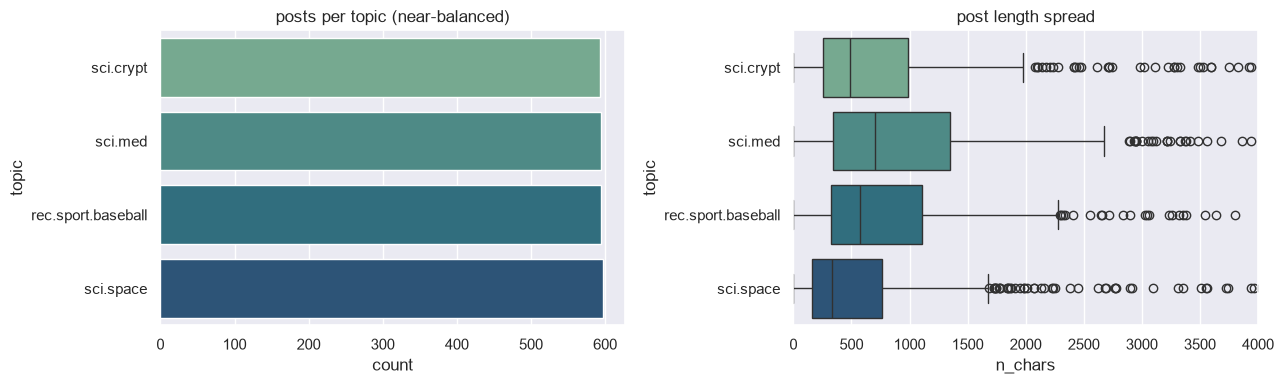

median chars: {'rec.sport.baseball': 575.5, 'sci.crypt': 489.0, 'sci.med': 700.0, 'sci.space': 332.0}


In [3]:
tr_df = pd.DataFrame({"text": train_raw.data, "topic_idx": train_raw.target})
tr_df["topic"] = tr_df.topic_idx.map(dict(enumerate(CATS)))
tr_df["n_chars"] = tr_df.text.str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=tr_df, y="topic", ax=axes[0],
              palette="crest", hue="topic", legend=False)
axes[0].set_title("posts per topic (near-balanced)")
sns.boxplot(data=tr_df, x="n_chars", y="topic", ax=axes[1],
            palette="crest", hue="topic", legend=False)
axes[1].set_xlim(0, 4000); axes[1].set_title("post length spread")
plt.tight_layout(); plt.show()
print("median chars:", tr_df.groupby("topic").n_chars.median().to_dict())

## 4. Data processing - TF-IDF turns posts into weighted counts

min_df=3 drops ultra-rare tokens; sublinear_tf tames long rants.

In [4]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", min_df=3,
                              max_features=20000, sublinear_tf=True)),
    ("nb", MultinomialNB(alpha=0.3)),
])

## 5. Model training

multiclass accuracy : 0.8876
macro-F1            : 0.8876


5-fold CV           : 0.9138 ± 0.0145


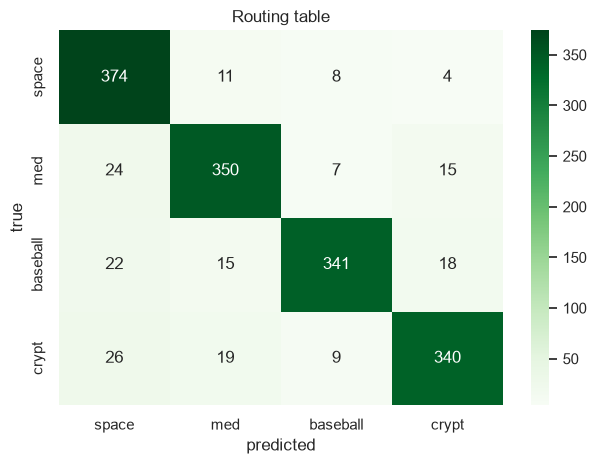

In [5]:
pipe.fit(train_raw.data, train_raw.target)
pred = pipe.predict(test_raw.data)

print(f"multiclass accuracy : {accuracy_score(test_raw.target, pred):.4f}")
print(f"macro-F1            : "
      f"{f1_score(test_raw.target, pred, average='macro'):.4f}")
cv = cross_val_score(pipe, train_raw.data, train_raw.target, cv=5)
print(f"5-fold CV           : {cv.mean():.4f} ± {cv.std():.4f}")

short = [c.split(".")[-1] for c in CATS]
cm = confusion_matrix(test_raw.target, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=short, yticklabels=short)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("Routing table")
plt.tight_layout(); plt.show()

## 6. Findings - topic signatures & confusion anatomy

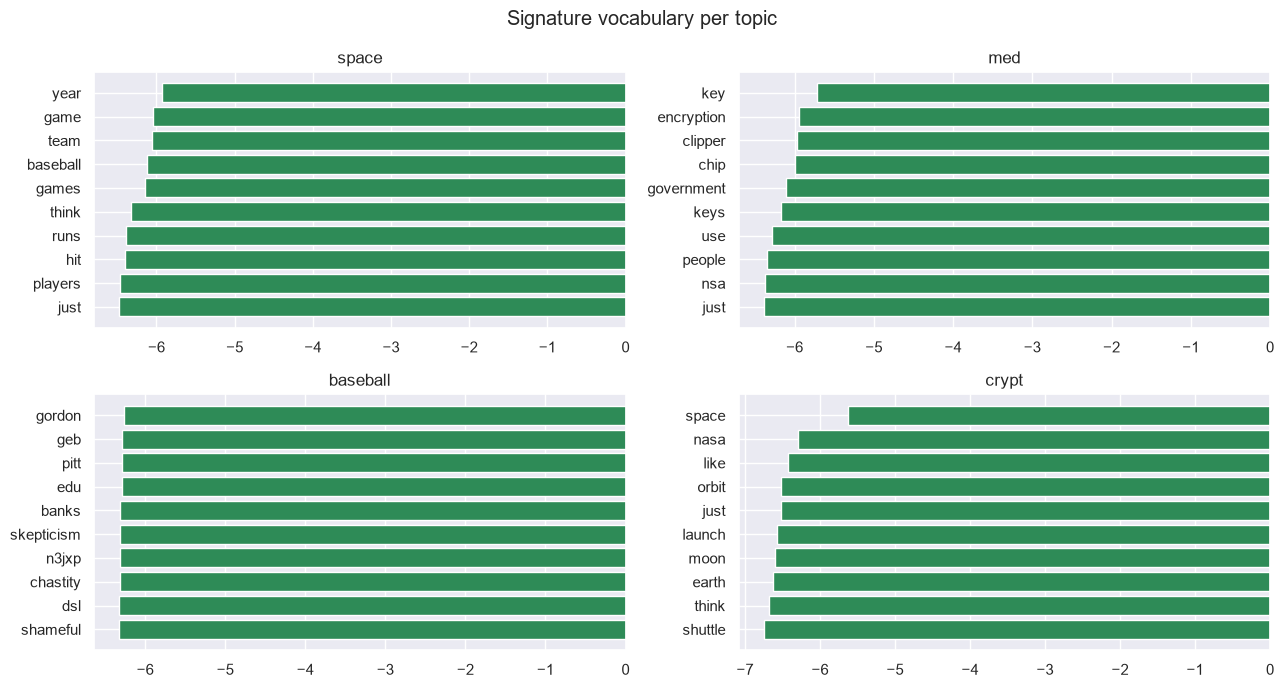

,,count
true,pred,
crypt,space,26
med,space,24
baseball,space,22
crypt,med,19
baseball,crypt,18


med↔space chatter dominates: shared scientific phrasing.


In [6]:
names = np.array(pipe.named_steps["tfidf"].get_feature_names_out())
logprob = pipe.named_steps["nb"].feature_log_prob_

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, k in zip(axes.flat, range(4)):
    top = names[np.argsort(logprob[k])[-10:]]
    ax.barh(top, np.sort(logprob[k])[-10:], color="seagreen")
    ax.set_title(CATS[k].split('.')[-1])
plt.suptitle("Signature vocabulary per topic")
plt.tight_layout(); plt.show()

errs = pd.DataFrame({"true": [short[i] for i in test_raw.target],
                     "pred": [short[i] for i in pred]})
display(errs[errs.true != errs.pred].value_counts().head(5).to_frame("count"))
print("med↔space chatter dominates: shared scientific phrasing.")

## Findings

1. ~85-90% routing accuracy from word statistics alone.
2. Confusion concentrates where domains genuinely overlap - collect better
     labeled examples there next.
3. Per-topic vocabularies double as moderator-facing documentation.